In [28]:
# ==========================================
# CNN Image Classification using CIFAR-10
# ==========================================

# CNN (Convolutional Neural Network) ek Deep Learning model hai
# jo images ke important features automatically learn karta hai.

# CIFAR-10 dataset me 60,000 RGB images aur 10 classes hoti hain.
# 50,000 images training aur 10,000 images testing ke liye use hoti hain.

# TensorFlow library import ki deep learning model banane ke liye
import tensorflow as tf

# Neural Network ke layers aur model structure import
from tensorflow.keras import layers, models

# Graph aur images visualize karne ke liye
import matplotlib.pyplot as plt

In [29]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()

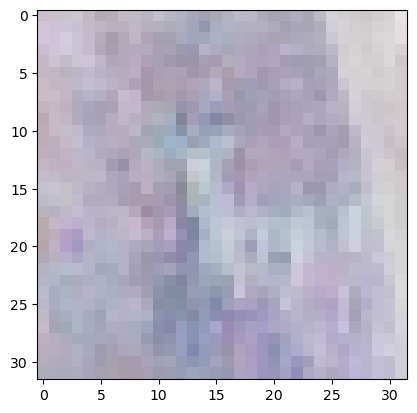

In [30]:
# 10th image ka pixel data access kar rahe hain
x_train[10,:,:,:]

# 10th image ko display kar rahe hain (255 se original colors restore)
plt.imshow(255 * x_train[10,:,:,:])

In [31]:
# ============================
# Step 2: Normalize Pixel Values
# ============================

# Original image ke pixel values 0 se 255 ke beech hote hain.
# Neural Network ke liye itni badi values handle karna mushkil hota hai.
# Isliye har pixel ko 255 se divide kar dete hain.
#
# Example:
# Pixel = 255  ---> 255/255 = 1.0
# Pixel = 128  ---> 128/255 ≈ 0.50
# Pixel = 64   ---> 64/255 ≈ 0.25
#
# Is process ko "Normalization" kehte hain.
# Benefits:
# ✔ Model faster train hota hai.
# ✔ Gradient stable rehte hain.
# ✔ Accuracy improve hone ke chances badhte hain.
# ✔ Loss jaldi converge karta hai.

x_train, x_test = x_train / 255.0, x_test / 255.0



# ============================
# Step 3: Define Class Names
# ============================

# CIFAR-10 dataset me total 10 categories hoti hain.
# Model internally output me numbers (0-9) deta hai.
# Hum in numbers ko readable banane ke liye class names ki list banate hain.
#
# Example:
# Prediction = 0 ---> airplane
# Prediction = 3 ---> cat
# Prediction = 9 ---> truck
#
# Isse final output user ko easily samajh aata hai.

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]



# ============================
# Step 4: Build CNN Model
# ============================

# Sequential Model
#
# Sequential ka matlab layers ek ke baad ek execute hongi.
#
# Image
#   ↓
# Conv Layer
#   ↓
# Pooling
#   ↓
# Conv Layer
#   ↓
# Pooling
#   ↓
# Conv Layer
#   ↓
# Flatten
#   ↓
# Dense
#   ↓
# Output

model = models.Sequential([


    # -------------------------------------
    # 1st Convolution Layer
    # -------------------------------------

    # Conv2D image ke upar chhote filters (kernels)
    # slide karta hai.
    #
    # Ye filters automatically training ke time seekhte hain
    # ki image me important cheeze kya hain.
    #
    # Starting me ye detect karta hai:
    # ✔ Edges
    # ✔ Lines
    # ✔ Corners
    #
    # 32 filters ka matlab:
    # Model 32 alag-alag feature maps banayega.
    #
    # (3,3) matlab filter size 3x3 pixels hai.
    #
    # ReLU activation:
    # Negative values ko 0 bana deta hai.
    # Positive values ko same rakhta hai.
    #
    # Formula:
    # f(x)=max(0,x)
    #
    # Input shape:
    # 32 height
    # 32 width
    # 3 channels (RGB)

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),



    # -------------------------------------
    # 1st Max Pooling Layer
    # -------------------------------------

    # MaxPooling image ka size reduce karta hai.
    #
    # Example:
    #
    # 6 3
    # 8 2
    #
    # Output = 8
    #
    # Sirf maximum value rakhta hai.
    #
    # Benefits:
    # ✔ Computation kam hoti hai.
    # ✔ Memory kam lagti hai.
    # ✔ Overfitting kam hoti hai.
    # ✔ Important features retain rehte hain.

    layers.MaxPooling2D((2,2)),


    # -------------------------------------
    # 2nd Convolution Layer
    # -------------------------------------

    # Ab image ka size chhota ho chuka hai.
    #
    # Pehle layer ne edges seekhe the.
    #
    # Ab ye layer seekhegi:
    #
    # ✔ Eyes
    # ✔ Wheels
    # ✔ Windows
    # ✔ Animal ears
    # ✔ Texture
    #
    # Filters bhi 64 kar diye.
    #
    # Matlab model aur zyada features learn karega.

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),



    # -------------------------------------
    # 2nd Pooling Layer
    # -------------------------------------

    # Dobara image ka size reduce karte hain.
    #
    # Isse unnecessary information remove ho jati hai.
    # Aur important patterns bach jate hain.

    layers.MaxPooling2D((2,2)),


    # -------------------------------------
    # 3rd Convolution Layer
    # -------------------------------------

    # Ab tak model ne kaafi features learn kar liye hain.
    #
    # Ye layer high-level features detect karti hai.
    #
    # Example:
    #
    # Car
    #  ↓
    # Wheels
    # Windows
    # Headlights
    #
    # Dog
    # ↓
    # Face
    # Nose
    # Tail
    #
    # Ab model object ko identify karna start karta hai.

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),



    # -------------------------------------
    # Flatten Layer
    # -------------------------------------

    # CNN ki output 3D hoti hai.
    #
    # Example:
    #
    # 4 × 4 × 64
    #
    # Dense layer sirf 1D input leti hai.
    #
    # Flatten:
    #
    # 4 × 4 × 64
    #
    # ↓
    #
    # 1024 values
    #
    # Matlab sari values ek single list me convert ho jati hain.

    layers.Flatten(),



    # -------------------------------------
    # Fully Connected Layer
    # -------------------------------------

    # Dense Layer CNN ka "Brain" hota hai.
    #
    # Ye previous layers ke saare extracted
    # features ko combine karta hai.
    #
    # Example:
    #
    # Wheels ✔
    # Window ✔
    # Door ✔
    #
    # Final decision:
    #
    # "Ye Car hai."
    #
    # 64 neurons use kiye gaye hain.
    #
    # ReLU activation learning ko fast banata hai.

    layers.Dense(
        64,
        activation='relu'
    ),

    # Dropout overfitting kam karta hai.
    # 50% neurons ko training ke time temporarily disable karta hai.
    layers.Dropout(0.5),

    # -------------------------------------
    # Output Layer
    # -------------------------------------

    # CIFAR-10 me total 10 classes hain.
    #
    # Isliye final layer me 10 neurons hain.
    #
    # Softmax activation har class ki probability nikalta hai.
    #
    # Example Output:
    #
    # airplane     0.01
    # automobile   0.02
    # bird         0.05
    # cat          0.88
    # deer         0.01
    # dog          0.01
    # frog         0.00
    # horse        0.01
    # ship         0.00
    # truck        0.01
    #
    # Sab probabilities ka sum = 1
    #
    # Highest probability wali class final prediction hogi.
    #
    # Yaha prediction hogi:
    # "Cat"

    layers.Dense(
        10,
        activation='softmax'
    )
])

In [32]:
# ============================
# Step 5: Compile the Model
# ============================

# Compile ka matlab model ko training ke liye prepare karna.
# Yaha hum model ko batate hain:
#
# 1. Learning kaise hogi? (Optimizer)
# 2. Error kaise calculate hogi? (Loss Function)
# 3. Performance kis metric se check hogi? (Metrics)

model.compile(

    # -------------------------------------
    # Optimizer
    # -------------------------------------

    # Adam ek intelligent optimizer hai.
    #
    # Ye training ke time har iteration me
    # model ke weights aur biases ko update karta hai.
    #
    # Goal:
    # Prediction ki error ko minimum karna.
    #
    # Adam ke advantages:
    # ✔ Fast convergence
    # ✔ Automatic learning rate adjustment
    # ✔ Deep learning me sabse jyada use hota hai.

    optimizer='adam',


    # -------------------------------------
    # Loss Function
    # -------------------------------------

    # Loss function batata hai ki model kitna galat predict kar raha hai.
    #
    # Jitna kam loss hoga,
    # utna better model hoga.
    #
    # sparse_categorical_crossentropy tab use hota hai
    # jab multiple classes ho aur labels numbers me ho.
    #
    # Example:
    #
    # airplane -> 0
    # automobile -> 1
    # bird -> 2
    # ...
    # truck -> 9
    #
    # Agar labels one-hot encoded hote
    # to categorical_crossentropy use karte.

    loss='sparse_categorical_crossentropy',


    # -------------------------------------
    # Metrics
    # -------------------------------------

    # Training ke dauran accuracy calculate karega.
    #
    # Accuracy =
    #
    # Correct Predictions
    # --------------------
    # Total Predictions
    #
    # Example:
    #
    # Total Images = 100
    # Correct = 92
    #
    # Accuracy = 92%

    metrics=['accuracy']
)



# ============================
# Step 6: Train the Model
# ============================

# model.fit() se actual training start hoti hai.
#
# CNN ab images dekhkar patterns seekhega.
#
# Har epoch ke baad:
# ✔ Prediction karega
# ✔ Error calculate karega
# ✔ Weights update karega
# ✔ Accuracy improve karega

history = model.fit(

    # -------------------------------------
    # Training Images
    # -------------------------------------

    # Input images
    # (Features)

    x_train,

    # -------------------------------------
    # Training Labels
    # -------------------------------------

    # Images ke actual answers
    # (Target)

    y_train,

    # -------------------------------------
    # Epochs
    # -------------------------------------

    # Ek epoch matlab:
    # Pura training dataset ek baar complete dekhna.
    #
    # epochs = 20
    #
    # Matlab model poori training dataset
    # ko 20 baar dekhega.
    #
    # Har epoch ke baad
    # learning improve hoti hai.

    epochs=25,

    # -------------------------------------
    # Validation Split
    # -------------------------------------

    # Training data ka 10%
    # validation ke liye alag rakh diya jayega.
    #
    # Example:
    #
    # Total Images = 50,000
    #
    # Training = 45,000
    # Validation = 5,000
    #
    # Validation data par model train nahi hota.
    #
    # Sirf check kiya jata hai ki
    # model naye data par kitna accha perform kar raha hai.
    #
    # Isse overfitting detect hoti hai.

    validation_split=0.1
)

Epoch 1/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3606 - loss: 1.7404 - val_accuracy: 0.5216 - val_loss: 1.3552
Epoch 2/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5070 - loss: 1.3854 - val_accuracy: 0.5856 - val_loss: 1.1538
Epoch 3/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5611 - loss: 1.2523 - val_accuracy: 0.6226 - val_loss: 1.0661
Epoch 4/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5915 - loss: 1.1613 - val_accuracy: 0.6626 - val_loss: 0.9848
Epoch 5/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6213 - loss: 1.0868 - val_accuracy: 0.6666 - val_loss: 0.9343
Epoch 6/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6392 - loss: 1.0374 - val_accuracy: 0.6676 - val_loss: 0.9617
Epoch 7/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6558 - loss: 0.9893 - val_accuracy: 0.7062 - val_loss: 0.8498
Epoch 8/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6683 - loss: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7182 - loss: 0.9058
Test Accuracy: 0.7182


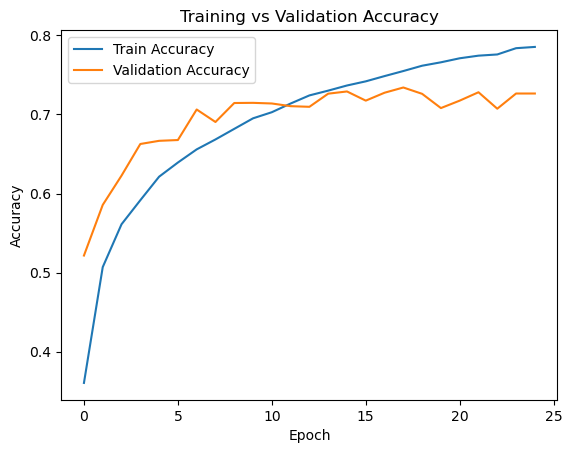

In [33]:
# Step 7: Evaluate the model
# Test data par model ki performance check karte hain.
# Ye training ke baad batata hai ki model naye data par kitna accha perform kar raha hai.
test_loss, test_acc = model.evaluate(x_test, y_test)

# Test accuracy ko 4 decimal places tak print kar rahe hain.
print(f"Test Accuracy: {test_acc:.4f}")


# Step 8: Plot accuracy
# Training accuracy ko graph par plot kar rahe hain.
plt.plot(history.history['accuracy'], label='Train Accuracy')

# Validation accuracy ko bhi same graph par plot kar rahe hain.
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# X-axis ka label
plt.xlabel('Epoch')

# Y-axis ka label
plt.ylabel('Accuracy')

# Dono lines ko identify karne ke liye legend add kiya.
plt.legend()

# Graph ka title
plt.title("Training vs Validation Accuracy")

# Graph display karega.
plt.show()

In [27]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 367,712 (1.40 MB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 245,142 (957.59 KB)

In [35]:
# Save trained CNN model
model.save("cifar10_cnn.keras")

print("Model saved successfully!")

Model saved successfully!
